# **Calibración Modelo Macro LP**

## 1. Librerias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve


if os.getcwd().split('\\')[len(os.getcwd().split('\\'))-1] != "202510-MacroLP-Proyecto":
    os.chdir("..")
print(os.getcwd())


## 2. Parámetros

In [ ]:
_lambda = 0.5
_gamma = np.array([0.20, 0.25, 0.30, 0.15, 0.10]) # Cognitivas, socioemocionales, rutinarias, juicio, capital
target_shares = np.array([0.21, 0.28, 0.21, 0.15, 0.15])

In [3]:
def residuals(A_f):
    Phi = np.sum(A_f**(_lambda-1) * _gamma)
    model_shares = (A_f**(_lambda-1) * _gamma) / Phi
    return model_shares - target_shares

# 3) Initial guess and solve
initial_guess = np.ones(len(_gamma))
A_f_solution, _, ier, _ = fsolve(residuals, initial_guess, full_output=True)

if ier == 1:
    print("Calibrated A_f:", A_f_solution)
else:
    print("Calibration failed. Try different initial guess or check data.")

Calibrated A_f: [1.64228893 1.443418   3.69515009 1.81062354 0.80472157]


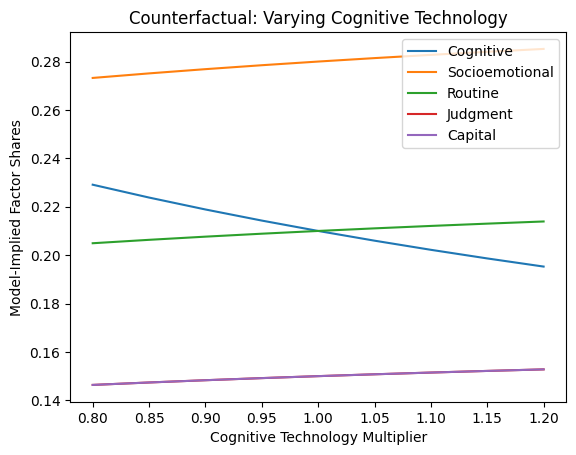

In [5]:
shock_multipliers = np.linspace(0.8, 1.2, 9)  # from -20% to +20%
shares = np.zeros((len(shock_multipliers), len(A_f_solution)))

# Compute model shares under each multiplier
for i, m in enumerate(shock_multipliers):
    A = A_f_solution.copy()
    A[0] = A_f_solution[0] * m
    Phi = np.sum(A**(_lambda - 1) * _gamma)
    shares[i, :] = (A**(_lambda - 1) * _gamma) / Phi

# Plot counterfactual
plt.figure()
labels = ['Cognitive', 'Socioemotional', 'Routine', 'Judgment', 'Capital']
for f in range(len(A_f_solution)):
    plt.plot(shock_multipliers, shares[:, f], label=labels[f])
plt.xlabel('Cognitive Technology Multiplier')
plt.ylabel('Model-Implied Factor Shares')
plt.title('Counterfactual: Varying Cognitive Technology')
plt.legend()
plt.show()